<a href="https://colab.research.google.com/github/miftahulhdd/MiftahulHudaAmri_2411533005_ML2526/blob/main/BaggingRandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Decision Tree vs Random Forest

In [3]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

acc_tree_train = accuracy_score(y_train, tree.predict(X_train))
acc_tree_test = accuracy_score(y_test, tree.predict(X_test))

print("Decision Tree Train:", acc_tree_train)
print("Decision Tree Test :", acc_tree_test)

Decision Tree Train: 1.0
Decision Tree Test : 0.9473684210526315


In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test = accuracy_score(y_test, rf.predict(X_test))

print("Random Forest Train:", acc_rf_train)
print("Random Forest Test :", acc_rf_test)

Random Forest Train: 1.0
Random Forest Test : 0.9649122807017544


Feature Importance

In [5]:
importances = rf.feature_importances_

feat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_importance.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


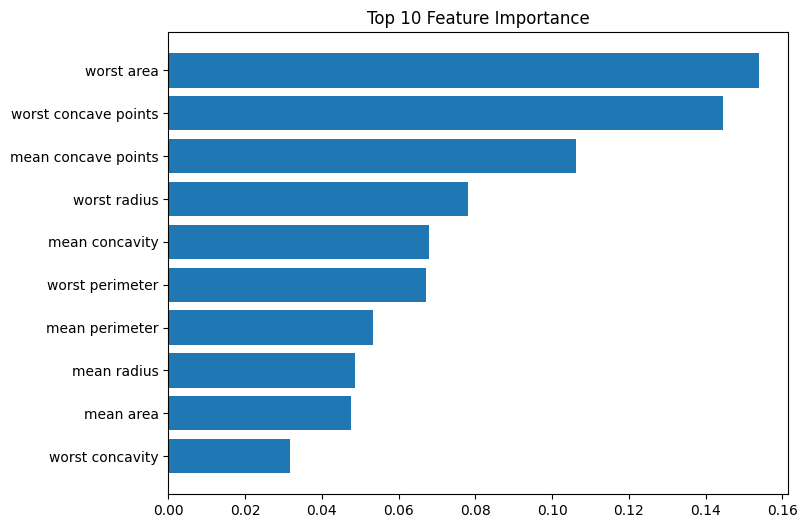

In [6]:
plt.figure(figsize=(8,6))
plt.barh(feat_importance["Feature"][:10],
         feat_importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.show()

Stability Test (Jumlah Estimator)

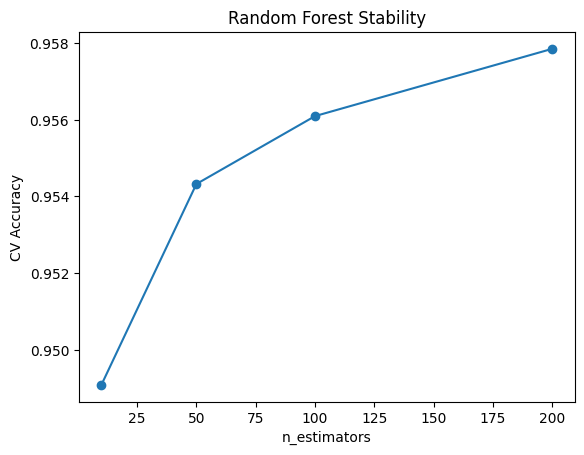

In [7]:
estimators = [10, 50, 100, 200]
rf_scores = []

for n in estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(model, X, y, cv=5).mean()
    rf_scores.append(score)

plt.plot(estimators, rf_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Stability")
plt.show()

PCA + Random Forest

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
score_rf_pca = cross_val_score(rf_pca, X_pca, y, cv=5).mean()

score_rf = cross_val_score(rf, X, y, cv=5).mean()

print("RF tanpa PCA:", score_rf)
print("RF dengan PCA:", score_rf_pca)

RF tanpa PCA: 0.9560937742586555
RF dengan PCA: 0.9507529886663562


tugas individu

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

print("Jumlah sampel:", X.shape[0])
print("Jumlah fitur original:", X.shape[1])

# Definisi variasi hyperparameter yang akan diuji
depths = [3, 5, 10, None]
max_features_options = ['sqrt', 'log2']
min_samples_leaf_options = [1, 2, 4]

rf_results = []

for depth in depths:
    for feat in max_features_options:
        for leaf in min_samples_leaf_options:
            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=depth,
                max_features=feat,
                min_samples_leaf=leaf,
                random_state=42,
                n_jobs=-1
            )
            # Menghitung CV score (5-fold)
            score = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

            rf_results.append({
                'max_depth': 'None' if depth is None else depth,
                'max_features': feat,
                'min_samples_leaf': leaf,
                'CV_Accuracy': score
            })

# Mengubah hasil ke DataFrame dan menampilkan tabel eksperimen
df_rf_results = pd.DataFrame(rf_results)
df_rf_results_sorted = df_rf_results.sort_values(by='CV_Accuracy', ascending=False).reset_index(drop=True)
df_rf_results_sorted

Jumlah sampel: 569
Jumlah fitur original: 30


,max_depth,max_features,min_samples_leaf,CV_Accuracy
0,10,log2,2,0.961357
1,None,log2,2,0.961357
2,5,sqrt,1,0.959618
3,5,sqrt,4,0.959618
4,10,sqrt,4,0.959618
5,None,sqrt,4,0.959618
6,None,log2,1,0.959603
7,10,log2,1,0.959603
8,5,log2,1,0.959603
9,5,log2,2,0.959587


In [14]:
# Standarisasi data untuk Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Inisialisasi dan pengujian Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
score_log_reg = cross_val_score(log_reg, X_scaled, y, cv=5, scoring='accuracy').mean()

# Mengambil model RF terbaik dari eksperimen sebelumnya untuk pembanding
best_rf_score = df_rf_results_sorted.iloc[0]['CV_Accuracy']
best_rf_params = f"depth={df_rf_results_sorted.iloc[0]['max_depth']}, feat={df_rf_results_sorted.iloc[0]['max_features']}, leaf={df_rf_results_sorted.iloc[0]['min_samples_leaf']}"

print("perbandingan model:")
print(f"Logistic Regression (dengan Scaling) : {score_log_reg:.5f}")
print(f"Random Forest Terbaik ({best_rf_params}) : {best_rf_score:.5f}")

perbandingan model:
Logistic Regression (dengan Scaling) : 0.98069
Random Forest Terbaik (depth=10, feat=log2, leaf=2) : 0.96136


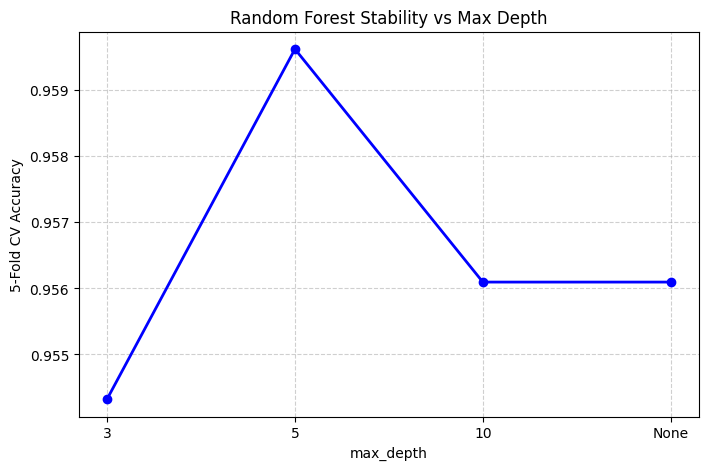

In [12]:
# Memfilter data eksperimen dengan parameter default lainnya konstan (min_samples_leaf=1, max_features='sqrt')
df_stability = df_rf_results[(df_rf_results['max_features'] == 'sqrt') & (df_rf_results['min_samples_leaf'] == 1)]

plt.figure(figsize=(8, 5))
plt.plot(df_stability['max_depth'].astype(str), df_stability['CV_Accuracy'], marker='o', linewidth=2, color='b')
plt.xlabel("max_depth")
plt.ylabel("5-Fold CV Accuracy")
plt.title("Random Forest Stability vs Max Depth")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()